In [1]:
!pip install transformers torchvision

In [2]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

text = "Sənin məhsul təsvirin bura yazılır"
inputs = tokenizer(text, padding='max_length', max_length=128, truncation=True, return_tensors="pt")

print(inputs['input_ids'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tensor([[  101,  1055, 29681, 11483,  1049, 29681,  7898,  5313,  1056, 29681,
          2015, 21663,  2378, 20934,  2527,  8038,  2480, 11722,  2140, 11722,
          2099,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,  

In [3]:
import kagglehub
import pandas as pd
import os
import shutil

path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
print("Dataset yükləndi:", path)

cache_dir = os.path.join(os.path.expanduser("~"), ".cache", "kagglehub")
print("Disk təmizlənir...")


csv_path = os.path.join(path, "fashion-dataset", "styles.csv")
df = pd.read_csv(csv_path, on_bad_lines='skip')

images_dir = os.path.join(path, "fashion-dataset", "images")
available_images = os.listdir(images_dir)
print(f"Cəmi {len(available_images)} şəkil tapıldı.")


Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Dataset yükləndi: /kaggle/input/fashion-product-images-dataset
Disk təmizlənir...
Cəmi 44441 şəkil tapıldı.


In [4]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [9]:
import os

df = df[['id', 'productDisplayName', 'masterCategory']]
df = df.dropna()

df['image_path'] = df['id'].apply(lambda x: os.path.join(path, "fashion-dataset", "images", f"{str(x)}.jpg"))

df = df[df['image_path'].apply(lambda x: os.path.exists(x))].reset_index(drop=True)

df = df.sample(min(5000, len(df)), random_state=42).reset_index(drop=True)

df['label'] = df['masterCategory'].astype('category').cat.codes
num_classes = len(df['masterCategory'].unique())

print(f"Təmizlənmiş data: {len(df)} məhsul və {num_classes} kateqoriya.")
df.head()

Təmizlənmiş data: 4999 məhsul və 6 kateqoriya.


,id,productDisplayName,masterCategory,image_path,label
0,29108,Puma Unisex FTPA Quarters Brown Socks,Accessories,/kaggle/input/fashion-product-images-dataset/f...,0
1,21629,Enamor Women Lift White Bra,Apparel,/kaggle/input/fashion-product-images-dataset/f...,1
2,23667,Spykar Men Navy Blue Check Shirt,Apparel,/kaggle/input/fashion-product-images-dataset/f...,1
3,28941,BIBA Women Ethnic Green Kurta,Apparel,/kaggle/input/fashion-product-images-dataset/f...,1
4,39728,Arrow Woman Women Pink Shirt,Apparel,/kaggle/input/fashion-product-images-dataset/f...,1


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

class MultiModalDataset(Dataset):
    def __init__(self, df, tokenizer, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.iloc[idx]['productDisplayName'])
        inputs = self.tokenizer(text, padding='max_length', max_length=32, truncation=True, return_tensors="pt")

        img_path = self.df.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.df.iloc[idx]['label'], dtype=torch.long)

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'image': image,
            'label': label
        }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = MultiModalDataset(df, tokenizer, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [11]:
import torch.nn as nn
from torchvision import models
from transformers import BertModel

class MultiModalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(MultiModalClassifier, self).__init__()
        self.text_model = BertModel.from_pretrained('bert-base-uncased')

        self.image_model = models.resnet18(pretrained=True)
        self.image_model.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(768 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, images):
        text_out = self.text_model(input_ids, attention_mask=attention_mask).pooler_output

        image_out = self.image_model(images)

        combined = torch.cat((text_out, image_out), dim=1)

        return self.classifier(combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiModalClassifier(num_classes).to(device)
print("Model uğurla yaradıldı və GPU-ya yükləndi!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/mod

Model uğurla yaradıldı və GPU-ya yükləndi!


In [12]:
import torch.optim as optim
from sklearn.metrics import f1_score
import numpy as np

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

epochs = 3

print("Öyrətmə başlayır...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask, images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Macro-F1: {f1:.4f}")

print("Təbriklər! Model öyrədildi.")

Öyrətmə başlayır...
Epoch 1/3 - Loss: 0.2822 - Macro-F1: 0.6175
Epoch 2/3 - Loss: 0.0193 - Macro-F1: 0.6657
Epoch 3/3 - Loss: 0.0174 - Macro-F1: 0.6641
Təbriklər! Model öyrədildi.


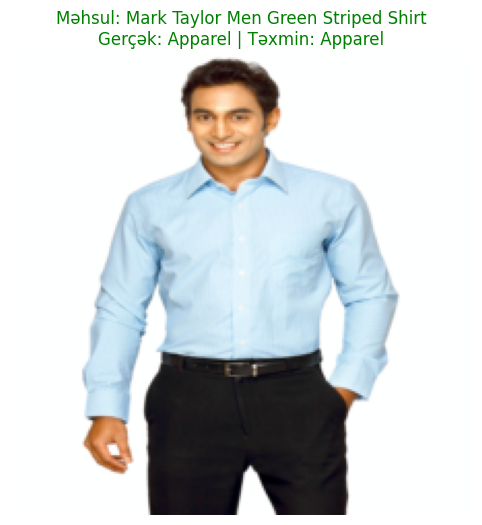

In [21]:
import matplotlib.pyplot as plt

def predict_random_product():
    model.eval()

    random_idx = np.random.randint(len(df))
    item = dataset[random_idx]

    input_ids = item['input_ids'].unsqueeze(0).to(device)
    attention_mask = item['attention_mask'].unsqueeze(0).to(device)
    image = item['image'].unsqueeze(0).to(device)
    true_label_idx = item['label'].item()

    with torch.no_grad():
        output = model(input_ids, attention_mask, image)
        pred_label_idx = torch.argmax(output, dim=1).item()

    categories = df['masterCategory'].astype('category').cat.categories
    true_category = categories[true_label_idx]
    pred_category = categories[pred_label_idx]

    img = item['image'].permute(1, 2, 0).cpu().numpy()

    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    product_name = df.iloc[random_idx]['productDisplayName']
    plt.title(f"Məhsul: {product_name}\nGerçək: {true_category} | Təxmin: {pred_category}",
              color='green' if true_label_idx == pred_label_idx else 'red')
    plt.axis('off')
    plt.show()

predict_random_product()

In [22]:
!pip install gradio -q
import gradio as gr
import torch

def predict_gradio(img, text):
    model.eval()


    img_tensor = transform(img).unsqueeze(0).to(device)

    inputs = tokenizer(text, padding='max_length', max_length=32, truncation=True, return_tensors="pt")
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        output = model(input_ids, attention_mask, img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()

    categories = df['masterCategory'].astype('category').cat.categories
    return categories[pred_idx]

demo = gr.Interface(
    fn=predict_gradio,
    inputs=[gr.Image(type="pil"), gr.Textbox(label="Məhsulun adı")],
    outputs=gr.Label(label="Təxmin edilən Kateqoriya"),
    title="Multi-Modal Məhsul Sinifləndirici",
    description="Şəkil və mətn əsasında məhsulun kateqoriyasını tapın."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fba17441ab0746c452.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
